# Note, DDF schedule subject to change depending on weather and updates to survey strategy

In [1]:
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline
from grab_ddf_sched import grab_ddf_sched
import pandas as pd

In [2]:
# Check the telescope config, download the save file 
# that has planned DDF observations, return array.
# Will skip download if file already exists
ddf_array = grab_ddf_sched()

In [3]:
# ddf_array is a ScheduledObservationArray object--defined here:
# https://github.com/lsst/rubin_scheduler/blob/main/rubin_scheduler/scheduler/utils/observation_array.py
ddf_array.dtype.names

('HA_min',
 'mjd',
 'flush_by_mjd',
 'observation_reason',
 'RA',
 'exptime',
 'target_name',
 'moon_min_distance',
 'HA_max',
 'scheduler_note',
 'dec',
 'band')

In [4]:
# Pretty pandas formatting.

# Note all angles (RA, dec, etc) are in radians.
# Hour Angle limits (HA_max, and HA_min) are in hours.

# Some values can be filled or altered at observations time. E.g., 
# the telescope rotation is typically set, and the RA and dec are shifted
# to a dithered position. The filter column will be filled with the 
# filter name used at the summit using the value in "band". 

# This array has all of the "observed" field set to False because
# we have not checked completed observations to see whish should
# be set to True. 
pd.DataFrame(ddf_array)

,HA_min,mjd,flush_by_mjd,observation_reason,RA,exptime,target_name,moon_min_distance,HA_max,scheduler_note,dec,band
0,21.0,61234.420138,61236.420138,ddf_xmm_lss,0.620901,38.0,ddf_xmm_lss,0.436332,3.0,DD:XMM_LSS,-0.084067,u
1,21.0,61234.420138,61236.420138,ddf_xmm_lss,0.620901,38.0,ddf_xmm_lss,0.436332,3.0,DD:XMM_LSS,-0.084067,u
2,21.0,61234.420138,61236.420138,ddf_xmm_lss,0.620901,38.0,ddf_xmm_lss,0.436332,3.0,DD:XMM_LSS,-0.084067,u
3,21.0,61260.357638,61262.357638,ddf_xmm_lss,0.620901,38.0,ddf_xmm_lss,0.436332,3.0,DD:XMM_LSS,-0.084067,u
4,21.0,61260.357638,61262.357638,ddf_xmm_lss,0.620901,38.0,ddf_xmm_lss,0.436332,3.0,DD:XMM_LSS,-0.084067,u
...,...,...,...,...,...,...,...,...,...,...,...,...
180357,21.0,62160.055554,62162.055554,ddf_edfs_b,1.110029,30.0,ddf_edfs_b,0.436332,3.0,DD:EDFS_b,-0.830777,z
180358,21.0,62160.055554,62162.055554,ddf_edfs_b,1.110029,30.0,ddf_edfs_b,0.436332,3.0,DD:EDFS_b,-0.830777,z
180359,21.0,62160.055554,62162.055554,ddf_edfs_b,1.110029,30.0,ddf_edfs_b,0.436332,3.0,DD:EDFS_b,-0.830777,z
180360,21.0,62160.055554,62162.055554,ddf_edfs_b,1.110029,30.0,ddf_edfs_b,0.436332,3.0,DD:EDFS_b,-0.830777,z


In [5]:
u_targets = np.unique(ddf_array["target_name"])

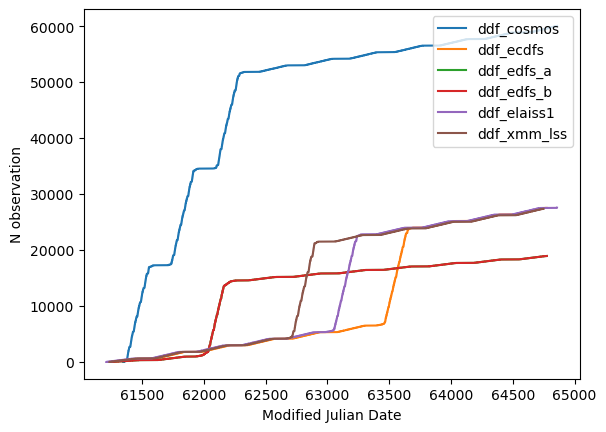

In [6]:
fig, ax = plt.subplots()
for target in u_targets:
    good = np.where(ddf_array["target_name"] == target)[0]
    num = np.arange(good.size)
    mjd = ddf_array["mjd"][good]
    ax.plot(np.sort(mjd), num, label=target)
ax.legend()
#plt.ylim([10,1e5])
ax.set_xlabel("Modified Julian Date")
ax.set_ylabel("N observation")

fig.savefig("ddf_schedule.png")